In [47]:
from dataExtraction import get_proteomics, get_genes

X_prot, X_meta = get_proteomics("data/sound_life_all_olink.csv", only_day_0=True)

Y, genes, ids_utilisés = get_genes("data/sound-life_whole-blood_no-stim.h5ad", X_prot, n_top_genes=300)
proteomics_raw = X_prot.loc[ids_utilisés].values
metadata = X_meta.loc[ids_utilisés]

/Users/paulmaricelle/Stanford/mini-projet/dataExtraction.py:7: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


There are : 6 samples in X without corresponding value in Y


In [48]:
proteomics_raw.shape, metadata.shape

((259, 1472), (259, 3))

In [49]:
import numpy as np
from sklearn.model_selection import GroupKFold
import pandas as pd

sex_encoded = pd.get_dummies(metadata['subject.biologicalSex'], drop_first=True)
metadata_numeric = pd.concat([sex_encoded, metadata['sample.subjectAgeAtDraw']], axis=1).astype(float)
metadata_numeric = metadata_numeric.values

groups = pd.factorize(metadata['subject.subjectGuid'])[0]

In [50]:
import torch

# Checking for Metal availabilty
if torch.mps.is_available():
    device = torch.device("mps")
    print("M4 GPU acceleration with Metal is ready")
else:
    device = torch.device("cpu")
    print("Metal not found, back on cpu")

M4 GPU acceleration with Metal is ready


 Fold 1/5 
Epoch : 1/100 , Train Loss : 1.0030136406421661 , Val Loss : 0.9289956092834473
Epoch : 10/100 , Train Loss : 0.3064349591732025 , Val Loss : 0.7419935464859009
Epoch : 20/100 , Train Loss : 0.17841222137212753 , Val Loss : 0.6814689636230469
Epoch : 30/100 , Train Loss : 0.14106924831867218 , Val Loss : 0.6643746495246887
Epoch : 40/100 , Train Loss : 0.12315639108419418 , Val Loss : 0.6685870289802551
Epoch : 50/100 , Train Loss : 0.12002161890268326 , Val Loss : 0.6703064441680908
Epoch : 60/100 , Train Loss : 0.12820184975862503 , Val Loss : 0.6702077984809875
Epoch : 70/100 , Train Loss : 0.11718215420842171 , Val Loss : 0.668605387210846
Epoch : 80/100 , Train Loss : 0.1274596005678177 , Val Loss : 0.6669424772262573
Epoch : 90/100 , Train Loss : 0.12322353944182396 , Val Loss : 0.6704643368721008
Epoch : 100/100 , Train Loss : 0.12030024453997612 , Val Loss : 0.6675238609313965
Constant genes skipped (r set to 0) : 0/300
 Median correlation is 0.319


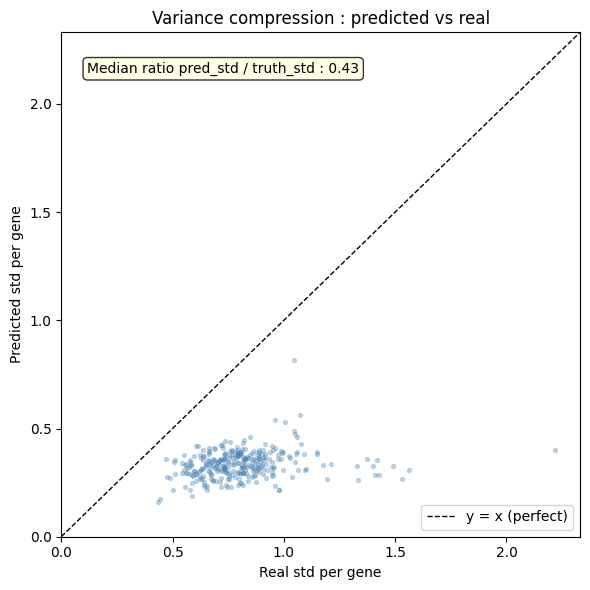

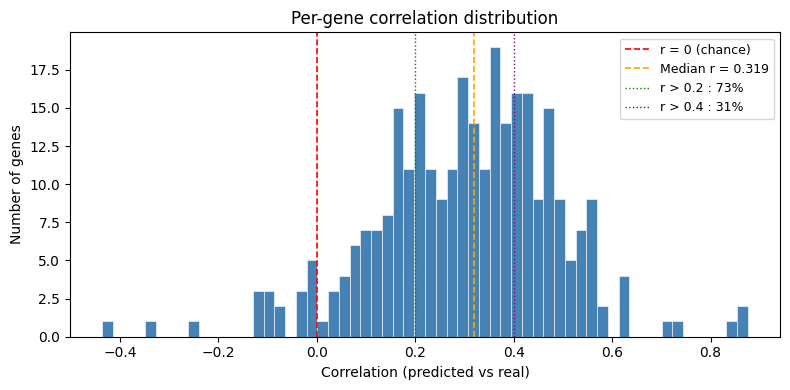

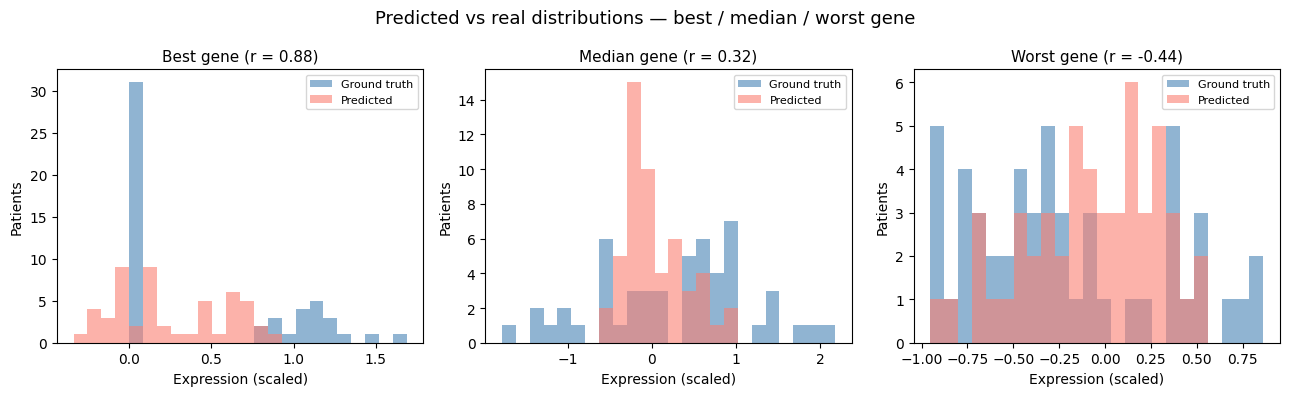

 Fold 2/5 
Epoch : 1/100 , Train Loss : 1.0351412296295166 , Val Loss : 0.8540017604827881
Epoch : 10/100 , Train Loss : 0.31627456843852997 , Val Loss : 0.7157087922096252
Epoch : 20/100 , Train Loss : 0.17385687679052353 , Val Loss : 0.6719558835029602
Epoch : 30/100 , Train Loss : 0.14091000705957413 , Val Loss : 0.6490524411201477
Epoch : 40/100 , Train Loss : 0.12787461280822754 , Val Loss : 0.6385220289230347
Epoch : 50/100 , Train Loss : 0.12306813895702362 , Val Loss : 0.6440725326538086
Epoch : 60/100 , Train Loss : 0.13140742108225822 , Val Loss : 0.6422945261001587
Epoch : 70/100 , Train Loss : 0.1267755776643753 , Val Loss : 0.6483985185623169
Epoch : 80/100 , Train Loss : 0.12467727810144424 , Val Loss : 0.6448132991790771
Epoch : 90/100 , Train Loss : 0.13424845784902573 , Val Loss : 0.6381818056106567
Epoch : 100/100 , Train Loss : 0.12218785658478737 , Val Loss : 0.636518120765686
Constant genes skipped (r set to 0) : 0/300
 Median correlation is 0.301


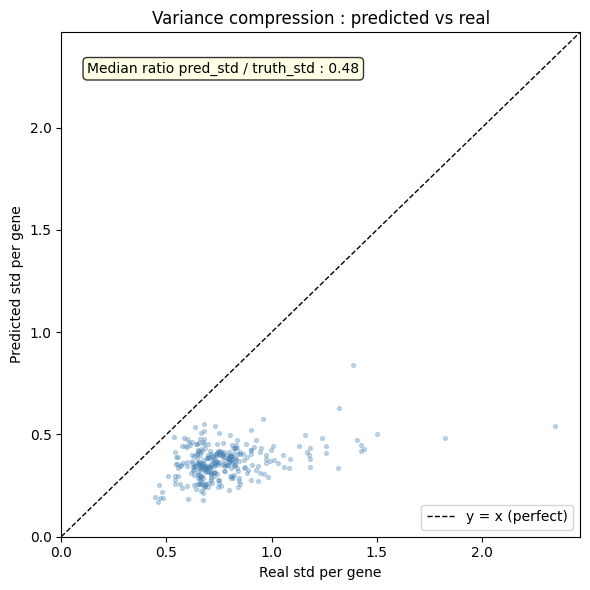

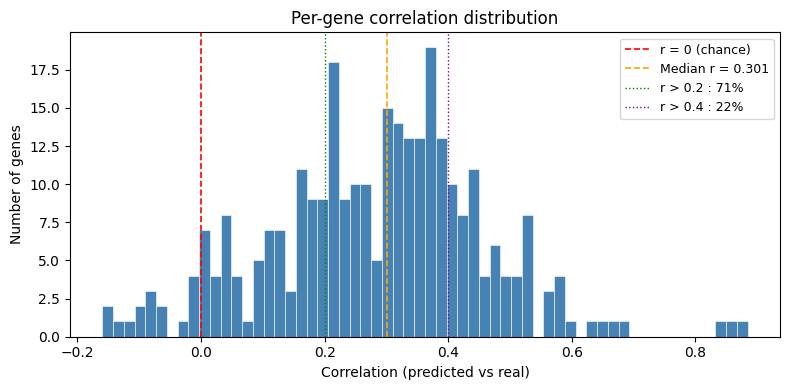

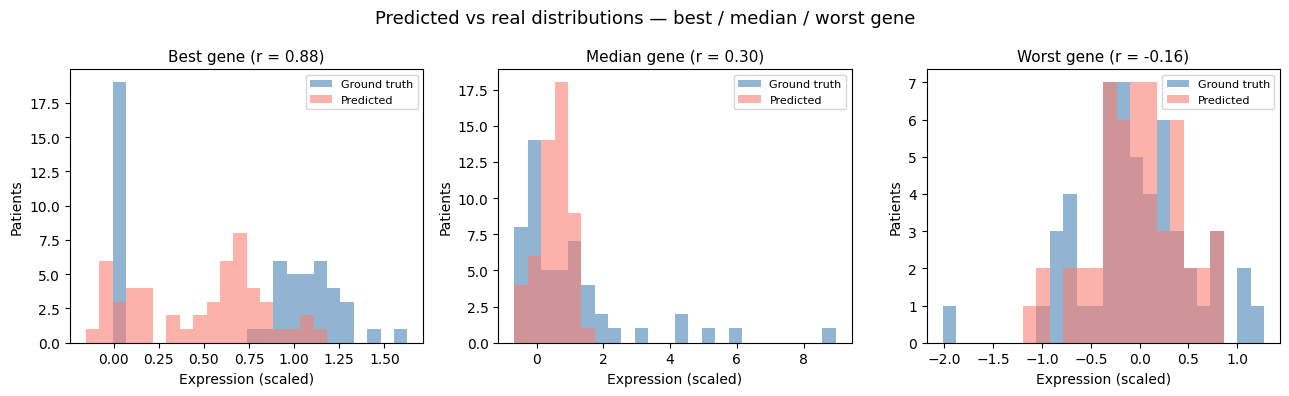

 Fold 3/5 
Epoch : 1/100 , Train Loss : 1.0277888774871826 , Val Loss : 0.6749611496925354
Epoch : 10/100 , Train Loss : 0.31073684990406036 , Val Loss : 0.5408931374549866
Epoch : 20/100 , Train Loss : 0.17479902505874634 , Val Loss : 0.4860388934612274
Epoch : 30/100 , Train Loss : 0.14055219292640686 , Val Loss : 0.4738622307777405
Epoch : 40/100 , Train Loss : 0.1301991268992424 , Val Loss : 0.46424826979637146
Epoch : 50/100 , Train Loss : 0.1289299726486206 , Val Loss : 0.4611368775367737
Epoch : 60/100 , Train Loss : 0.13046987727284431 , Val Loss : 0.4598301947116852
Epoch : 70/100 , Train Loss : 0.13100699707865715 , Val Loss : 0.470319002866745
Epoch : 80/100 , Train Loss : 0.12624379247426987 , Val Loss : 0.4651820957660675
Epoch : 90/100 , Train Loss : 0.12748423218727112 , Val Loss : 0.46538448333740234
Epoch : 100/100 , Train Loss : 0.12809062004089355 , Val Loss : 0.4639042913913727
Constant genes skipped (r set to 0) : 0/300
 Median correlation is 0.367


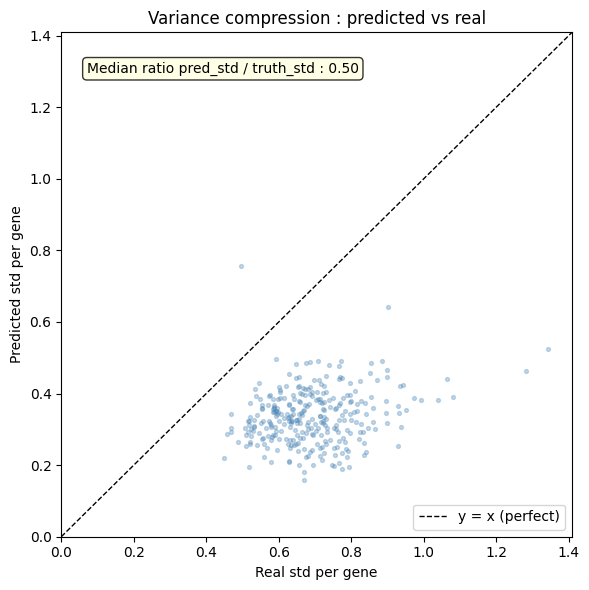

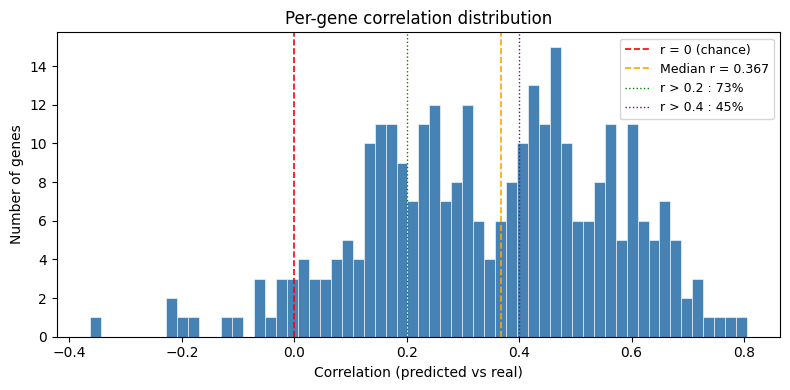

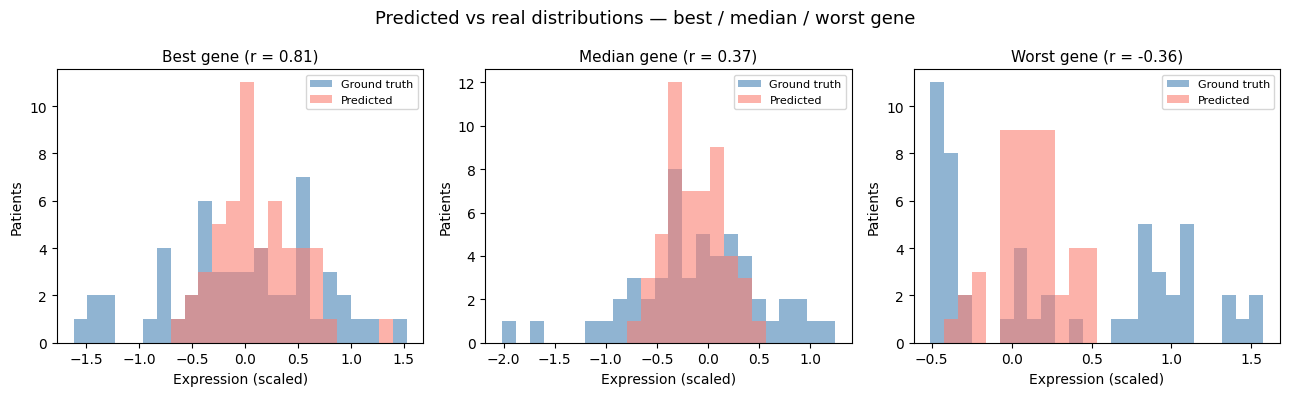

 Fold 4/5 
Epoch : 1/100 , Train Loss : 0.9900678992271423 , Val Loss : 0.8787763714790344
Epoch : 10/100 , Train Loss : 0.2998757064342499 , Val Loss : 0.7292500734329224
Epoch : 20/100 , Train Loss : 0.1701110601425171 , Val Loss : 0.6763824224472046
Epoch : 30/100 , Train Loss : 0.13040252774953842 , Val Loss : 0.6623154878616333
Epoch : 40/100 , Train Loss : 0.12416356429457664 , Val Loss : 0.6638485193252563
Epoch : 50/100 , Train Loss : 0.12421651184558868 , Val Loss : 0.660190224647522
Epoch : 60/100 , Train Loss : 0.1231379397213459 , Val Loss : 0.6587866544723511
Epoch : 70/100 , Train Loss : 0.13103211671113968 , Val Loss : 0.6616120338439941
Epoch : 80/100 , Train Loss : 0.1300562024116516 , Val Loss : 0.6645066142082214
Epoch : 90/100 , Train Loss : 0.12905624881386757 , Val Loss : 0.6561593413352966
Epoch : 100/100 , Train Loss : 0.13256089016795158 , Val Loss : 0.6515135765075684
Constant genes skipped (r set to 0) : 0/300
 Median correlation is 0.314


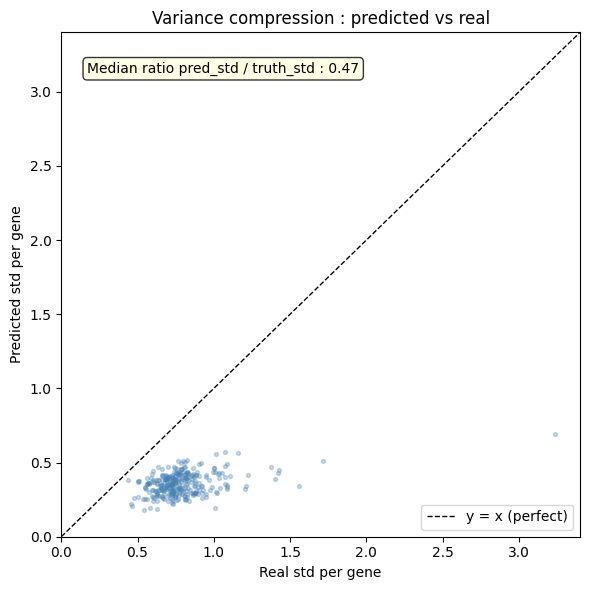

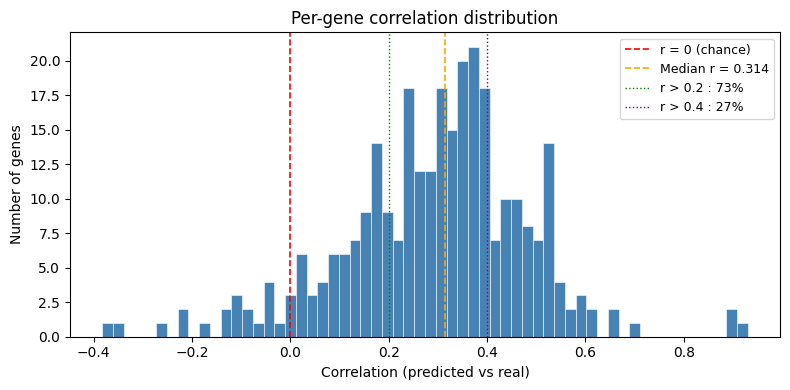

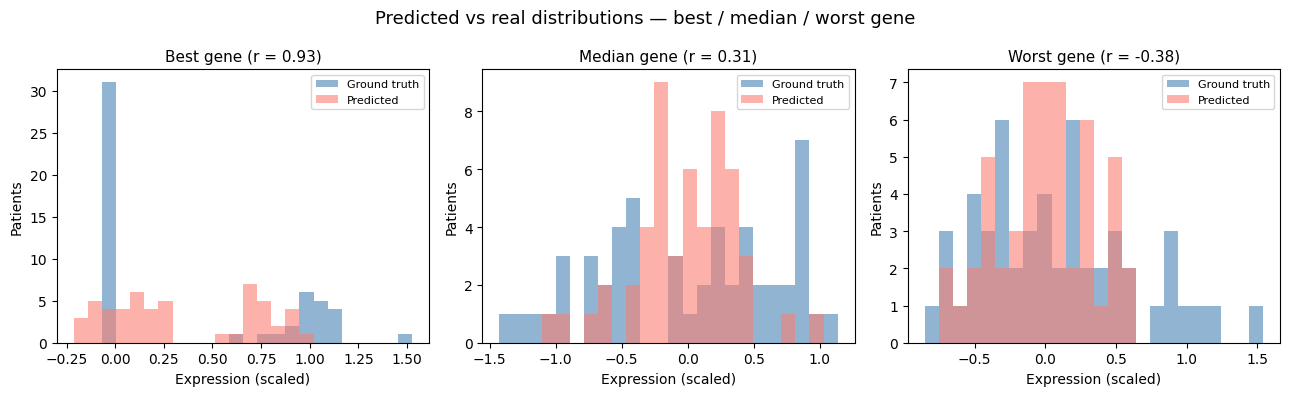

 Fold 5/5 
Epoch : 1/100 , Train Loss : 1.0355549156665802 , Val Loss : 0.7985630631446838
Epoch : 10/100 , Train Loss : 0.3066355735063553 , Val Loss : 0.6759164333343506
Epoch : 20/100 , Train Loss : 0.18183062970638275 , Val Loss : 0.6293351650238037
Epoch : 30/100 , Train Loss : 0.14217877388000488 , Val Loss : 0.6086634397506714
Epoch : 40/100 , Train Loss : 0.1343902349472046 , Val Loss : 0.6019187569618225
Epoch : 50/100 , Train Loss : 0.1316048726439476 , Val Loss : 0.6073887944221497
Epoch : 60/100 , Train Loss : 0.1250338964164257 , Val Loss : 0.6126481294631958
Epoch : 70/100 , Train Loss : 0.13702940195798874 , Val Loss : 0.6153676509857178
Epoch : 80/100 , Train Loss : 0.13102993369102478 , Val Loss : 0.603443443775177
Epoch : 90/100 , Train Loss : 0.12643224745988846 , Val Loss : 0.6092489957809448
Epoch : 100/100 , Train Loss : 0.1231643334031105 , Val Loss : 0.5979920029640198
Constant genes skipped (r set to 0) : 0/300
 Median correlation is 0.343


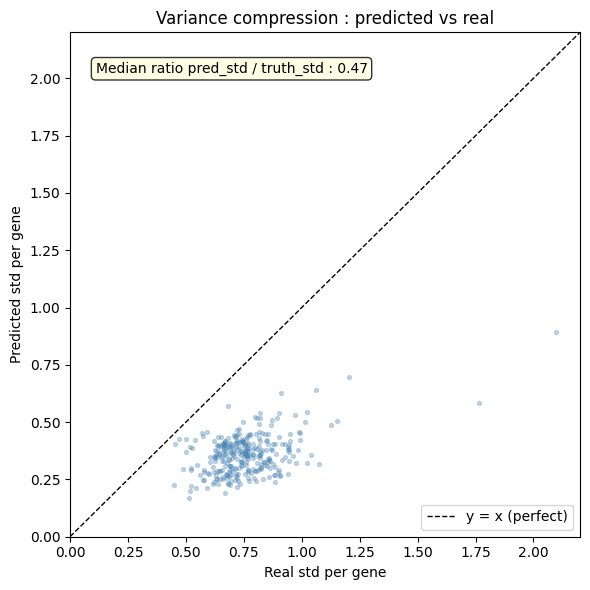

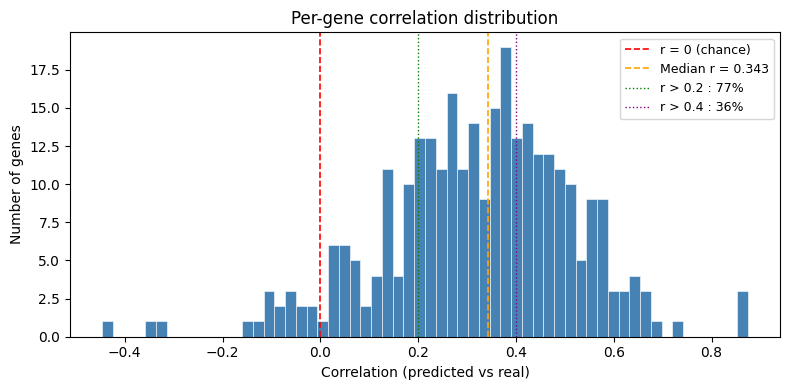

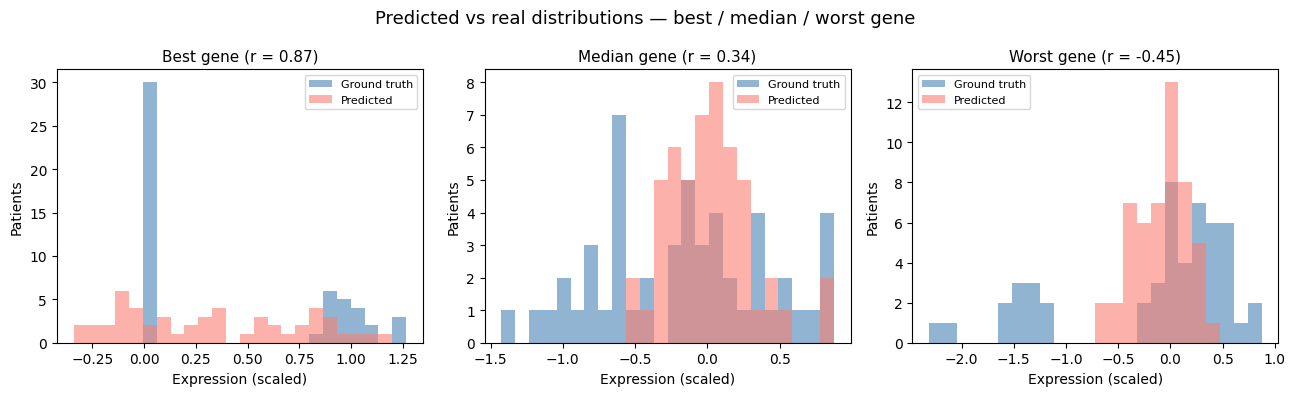

In [83]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import RobustScaler
import torch.optim as optim
import torch.nn as nn
from utils import train_and_evaluate_with_dispersion_plots
from variancePenaltyLoss import VariancePenaltyLoss

n_splits = 5
gkf = GroupKFold(n_splits=n_splits)

for fold, (train_idx, test_idx) in enumerate(gkf.split(proteomics_raw, Y, groups=groups)):
    print(f" Fold {fold + 1}/{n_splits} ")
    
    # Data split
    prot_train, prot_test = proteomics_raw[train_idx], proteomics_raw[test_idx]
    meta_train, meta_test = metadata_numeric[train_idx], metadata_numeric[test_idx]
    y_train, y_test = Y[train_idx], Y[test_idx]
    
    # Impute
    imputer = KNNImputer(n_neighbors=5)
    prot_train_imputed = imputer.fit_transform(prot_train)
    prot_test_imputed = imputer.transform(prot_test)
    
    # Combining proteomics and metadata
    X_train_combined = np.hstack([prot_train_imputed, meta_train])
    X_test_combined = np.hstack([prot_test_imputed, meta_test])
    
    # Applying the scaling
    scaler_x = RobustScaler()
    X_train_scaled = scaler_x.fit_transform(X_train_combined)
    X_test_scaled = scaler_x.transform(X_test_combined)
    
    scaler_y = RobustScaler()
    y_train_scaled = scaler_y.fit_transform(y_train)
    y_test_scaled = scaler_y.transform(y_test)
    
    # Initializing tenzors
    X_tensor_train = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
    Y_tensor_train = torch.tensor(y_train_scaled, dtype=torch.float32).to(device)
    X_tensor_test = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
    Y_tensor_test = torch.tensor(y_test_scaled, dtype=torch.float32).to(device)
    
    dataset_train = torch.utils.data.TensorDataset(X_tensor_train, Y_tensor_train)
    dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=128, shuffle=True)
    
    # Init model for this fold
    """ model = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(X_train_scaled.shape[1], 4*X_train_scaled.shape[1]),
        nn.ReLU(),
        nn.LayerNorm((4*X_train_scaled.shape[1])),
        nn.Dropout(p=0.4),
        nn.Linear(4*X_train_scaled.shape[1], y_train_scaled.shape[1])
    ).to(device)

    This leads to overfitting """

    model = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(X_train_scaled.shape[1], y_train_scaled.shape[1]),
    ).to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=0.01)
    
    loss_fn = nn.MSELoss()

    
    
    train_and_evaluate_with_dispersion_plots(
        model=model, 
        train_loader=dataloader_train, 
        X_test=X_tensor_test, 
        Y_test=Y_tensor_test, 
        optimizer=optimizer, 
        loss=loss_fn, 
        epochs=100
    )
    

 Fold 1/5 with PCA on X
Epoch : 1/300 , Train Loss : 13.78014087677002 , Val Loss : 7.075062274932861
Epoch : 10/300 , Train Loss : 10.928566455841064 , Val Loss : 5.694871425628662
Epoch : 20/300 , Train Loss : 7.856164216995239 , Val Loss : 4.432194232940674
Epoch : 30/300 , Train Loss : 6.0093607902526855 , Val Loss : 3.4658637046813965
Epoch : 40/300 , Train Loss : 4.8062663078308105 , Val Loss : 2.746674060821533
Epoch : 50/300 , Train Loss : 3.6097614765167236 , Val Loss : 2.1921188831329346
Epoch : 60/300 , Train Loss : 2.696813464164734 , Val Loss : 1.7748509645462036
Epoch : 70/300 , Train Loss : 2.083441436290741 , Val Loss : 1.4664838314056396
Epoch : 80/300 , Train Loss : 1.6105315685272217 , Val Loss : 1.2390453815460205
Epoch : 90/300 , Train Loss : 1.2740805745124817 , Val Loss : 1.0744303464889526
Epoch : 100/300 , Train Loss : 1.0748836994171143 , Val Loss : 0.9560840129852295
Epoch : 110/300 , Train Loss : 0.8858225345611572 , Val Loss : 0.8680101633071899
Epoch : 120

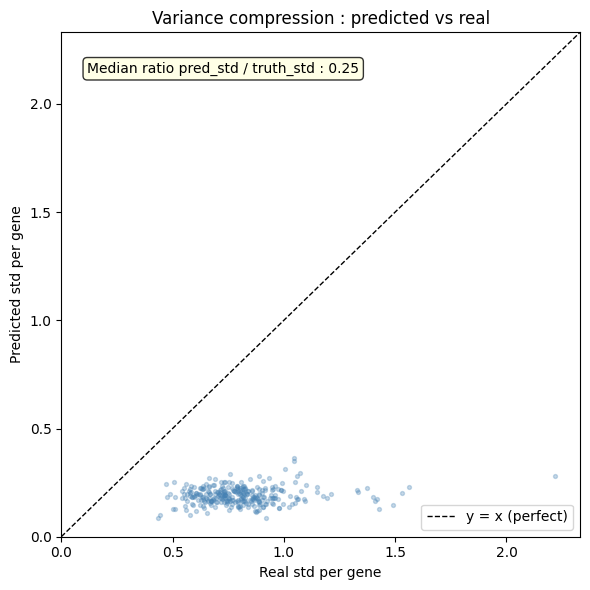

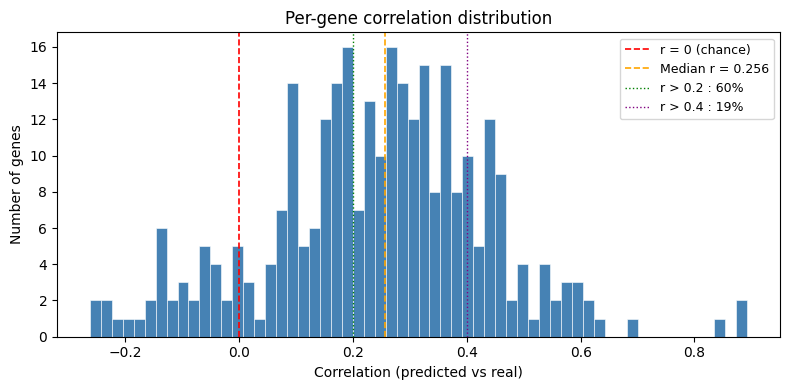

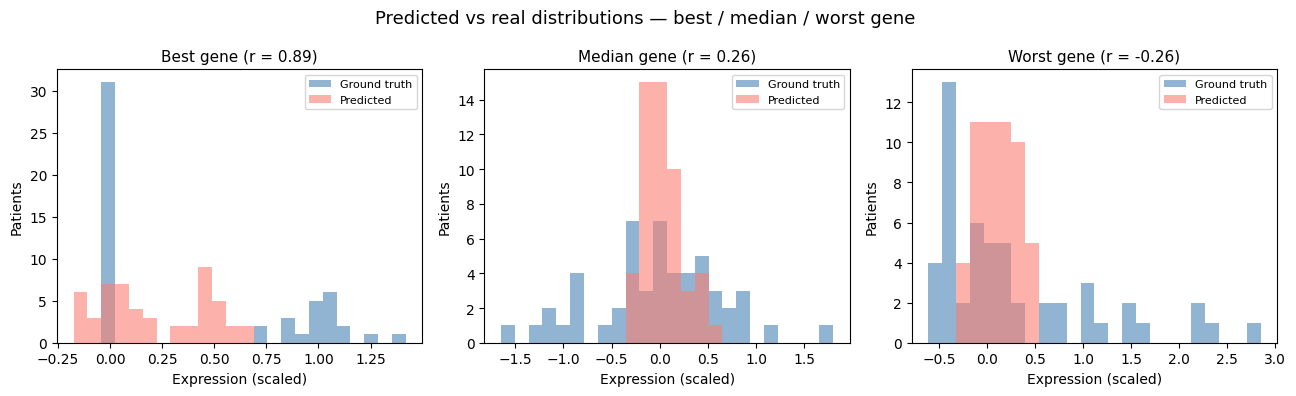

 Fold 2/5 with PCA on X
Epoch : 1/300 , Train Loss : 14.219066143035889 , Val Loss : 6.190090179443359
Epoch : 10/300 , Train Loss : 10.399489879608154 , Val Loss : 4.994830131530762
Epoch : 20/300 , Train Loss : 8.176083087921143 , Val Loss : 3.922637462615967
Epoch : 30/300 , Train Loss : 6.142293214797974 , Val Loss : 3.098597526550293
Epoch : 40/300 , Train Loss : 4.675098180770874 , Val Loss : 2.4591755867004395
Epoch : 50/300 , Train Loss : 3.7241417169570923 , Val Loss : 1.9567970037460327
Epoch : 60/300 , Train Loss : 2.7818996906280518 , Val Loss : 1.5886788368225098
Epoch : 70/300 , Train Loss : 2.2825342416763306 , Val Loss : 1.3203405141830444
Epoch : 80/300 , Train Loss : 1.651254117488861 , Val Loss : 1.1239089965820312
Epoch : 90/300 , Train Loss : 1.3345941305160522 , Val Loss : 0.9836668372154236
Epoch : 100/300 , Train Loss : 1.0345591604709625 , Val Loss : 0.882197916507721
Epoch : 110/300 , Train Loss : 0.8786250352859497 , Val Loss : 0.8103557825088501
Epoch : 120/

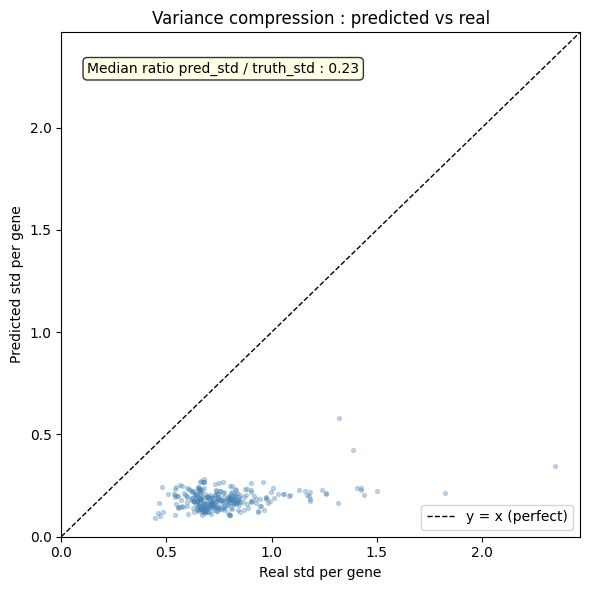

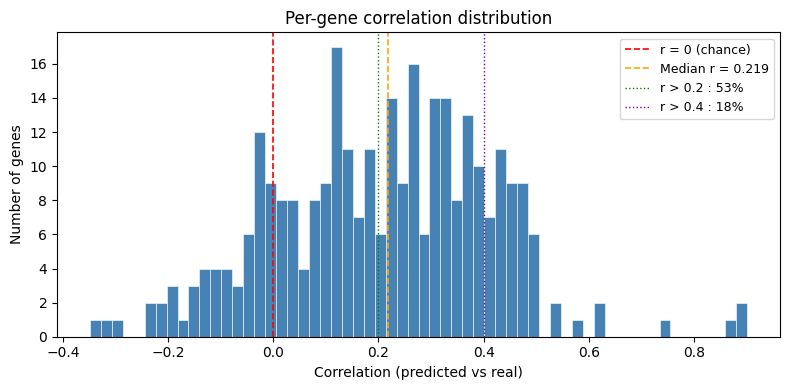

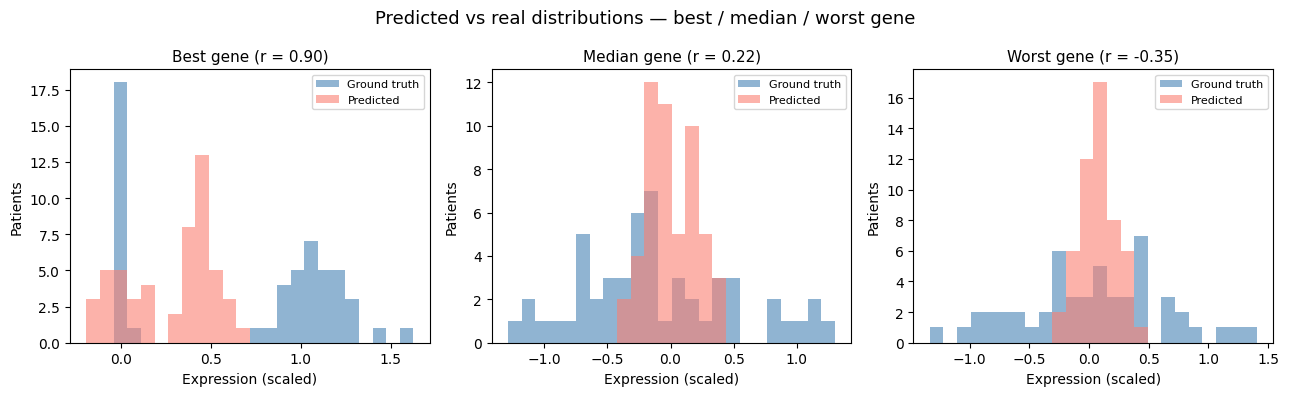

 Fold 3/5 with PCA on X
Epoch : 1/300 , Train Loss : 14.067038536071777 , Val Loss : 5.96004581451416
Epoch : 10/300 , Train Loss : 11.322473049163818 , Val Loss : 4.756004333496094
Epoch : 20/300 , Train Loss : 8.065471649169922 , Val Loss : 3.684351921081543
Epoch : 30/300 , Train Loss : 6.512754201889038 , Val Loss : 2.849857807159424
Epoch : 40/300 , Train Loss : 4.911417484283447 , Val Loss : 2.220492362976074
Epoch : 50/300 , Train Loss : 3.8782763481140137 , Val Loss : 1.7499115467071533
Epoch : 60/300 , Train Loss : 2.710746645927429 , Val Loss : 1.390376329421997
Epoch : 70/300 , Train Loss : 2.1827807426452637 , Val Loss : 1.1245921850204468
Epoch : 80/300 , Train Loss : 1.7845446467399597 , Val Loss : 0.9365360140800476
Epoch : 90/300 , Train Loss : 1.3350456953048706 , Val Loss : 0.8001860976219177
Epoch : 100/300 , Train Loss : 1.118951678276062 , Val Loss : 0.7004186511039734
Epoch : 110/300 , Train Loss : 0.9040311276912689 , Val Loss : 0.6315311789512634
Epoch : 120/300

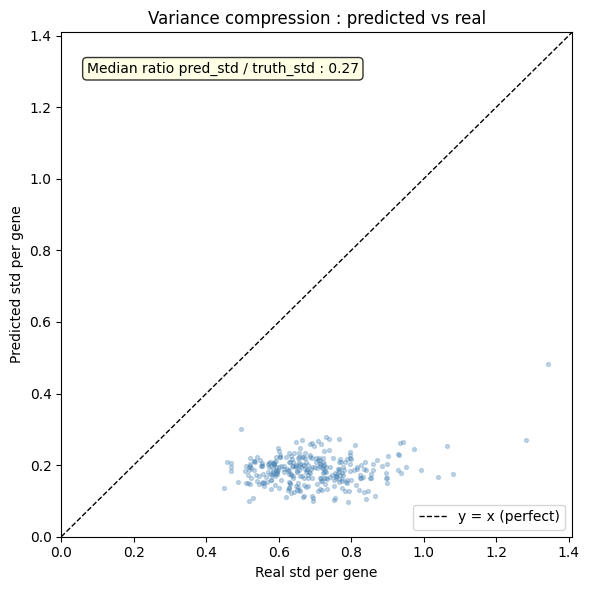

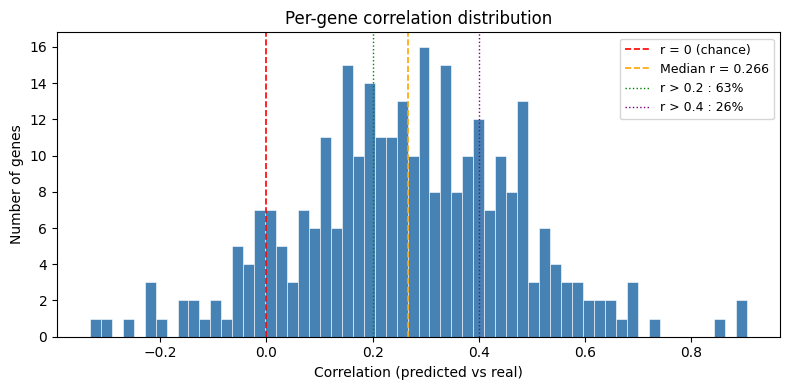

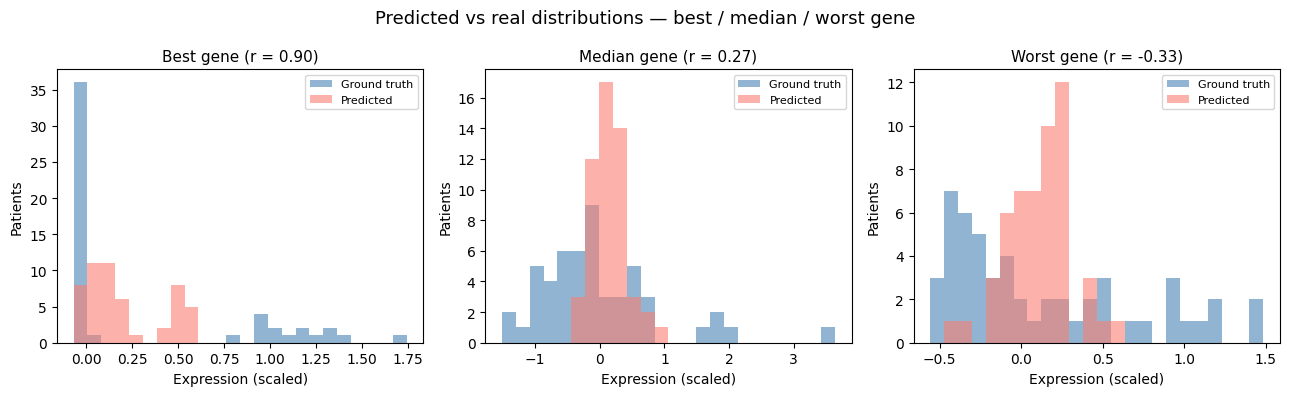

 Fold 4/5 with PCA on X
Epoch : 1/300 , Train Loss : 13.883677959442139 , Val Loss : 7.962374210357666
Epoch : 10/300 , Train Loss : 10.33224630355835 , Val Loss : 6.368331432342529
Epoch : 20/300 , Train Loss : 8.377665042877197 , Val Loss : 4.942085266113281
Epoch : 30/300 , Train Loss : 6.247239589691162 , Val Loss : 3.835771083831787
Epoch : 40/300 , Train Loss : 4.566922903060913 , Val Loss : 2.99503755569458
Epoch : 50/300 , Train Loss : 3.533254623413086 , Val Loss : 2.3793013095855713
Epoch : 60/300 , Train Loss : 2.820331573486328 , Val Loss : 1.8917919397354126
Epoch : 70/300 , Train Loss : 2.123844861984253 , Val Loss : 1.529314637184143
Epoch : 80/300 , Train Loss : 1.6165876984596252 , Val Loss : 1.2692970037460327
Epoch : 90/300 , Train Loss : 1.2931125164031982 , Val Loss : 1.084694504737854
Epoch : 100/300 , Train Loss : 1.0552509427070618 , Val Loss : 0.9559697508811951
Epoch : 110/300 , Train Loss : 0.8598473966121674 , Val Loss : 0.8621231317520142
Epoch : 120/300 , 

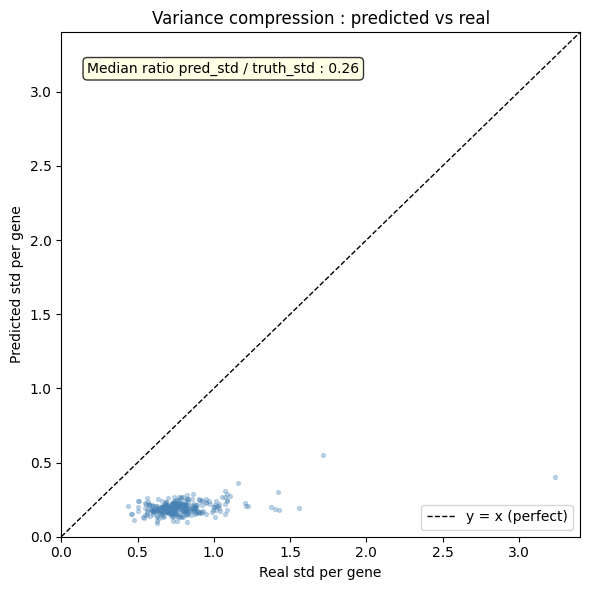

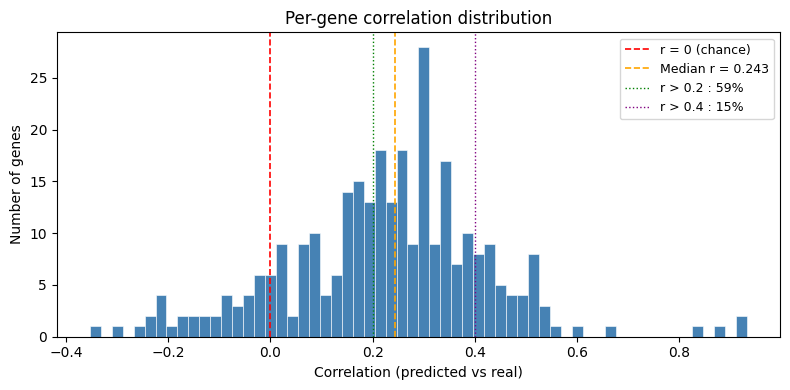

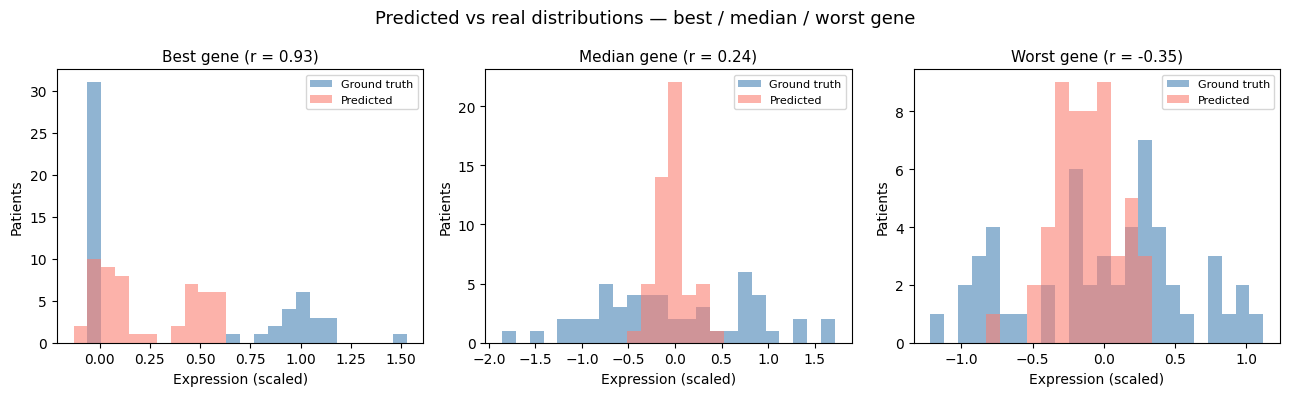

 Fold 5/5 with PCA on X
Epoch : 1/300 , Train Loss : 14.207820415496826 , Val Loss : 6.153428077697754
Epoch : 10/300 , Train Loss : 11.418672561645508 , Val Loss : 4.957132339477539
Epoch : 20/300 , Train Loss : 8.83074951171875 , Val Loss : 3.903562068939209
Epoch : 30/300 , Train Loss : 6.1468305587768555 , Val Loss : 3.0780906677246094
Epoch : 40/300 , Train Loss : 5.102145195007324 , Val Loss : 2.432831287384033
Epoch : 50/300 , Train Loss : 3.6796807050704956 , Val Loss : 1.9392225742340088
Epoch : 60/300 , Train Loss : 3.067096471786499 , Val Loss : 1.567206859588623
Epoch : 70/300 , Train Loss : 2.2687636613845825 , Val Loss : 1.2878249883651733
Epoch : 80/300 , Train Loss : 1.7530497908592224 , Val Loss : 1.0845454931259155
Epoch : 90/300 , Train Loss : 1.3639585375785828 , Val Loss : 0.9369393587112427
Epoch : 100/300 , Train Loss : 1.0794534087181091 , Val Loss : 0.8323150277137756
Epoch : 110/300 , Train Loss : 0.922256737947464 , Val Loss : 0.7577365040779114
Epoch : 120/3

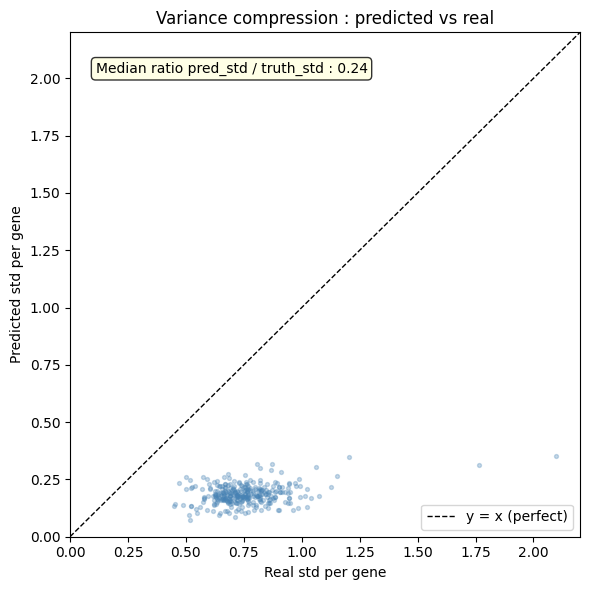

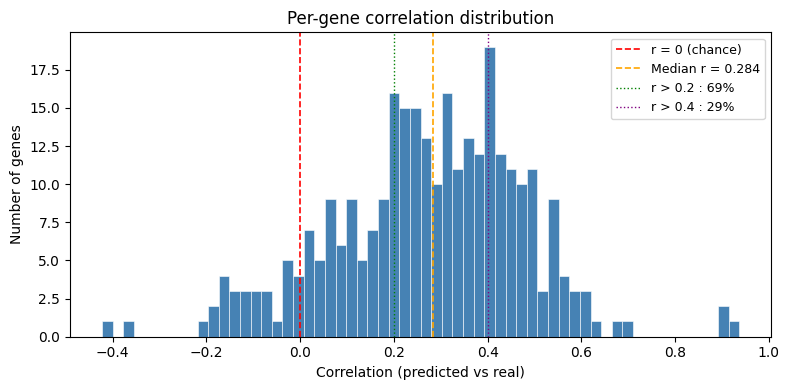

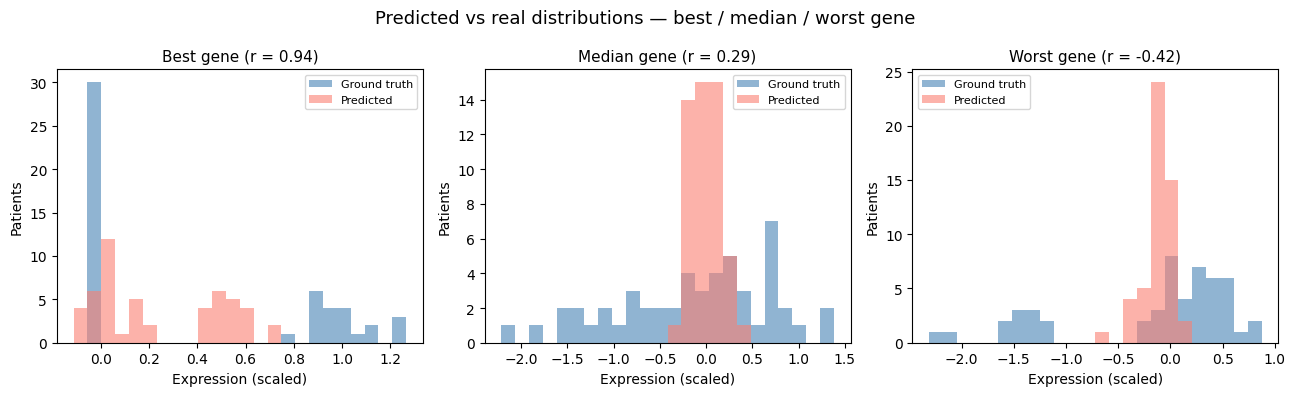

In [ ]:

from sklearn.decomposition import PCA
from utils import train_and_evaluate_with_dispersion_plots

n_splits = 5
gkf = GroupKFold(n_splits=n_splits)

# Number of components for X PCA
n_components_x = 20

for fold, (train_idx, test_idx) in enumerate(gkf.split(proteomics_raw, Y, groups=groups)):
    print(f" Fold {fold + 1}/{n_splits} with PCA on X")
    
    # Data split
    prot_train, prot_test = proteomics_raw[train_idx], proteomics_raw[test_idx]
    meta_train, meta_test = metadata_numeric[train_idx], metadata_numeric[test_idx]
    y_train, y_test = Y[train_idx], Y[test_idx]
    
    # Impute
    imputer = KNNImputer(n_neighbors=5)
    prot_train_imputed = imputer.fit_transform(prot_train)
    prot_test_imputed = imputer.transform(prot_test)
    
    # Combining proteomics and metadata
    X_train_combined = np.hstack([prot_train_imputed, meta_train])
    X_test_combined = np.hstack([prot_test_imputed, meta_test])
    
    # Applying the scaling
    scaler_x = RobustScaler()
    X_train_scaled = scaler_x.fit_transform(X_train_combined)
    X_test_scaled = scaler_x.transform(X_test_combined)
    
    scaler_y = RobustScaler()
    y_train_scaled = scaler_y.fit_transform(y_train)
    y_test_scaled = scaler_y.transform(y_test)
    
    # Preparing the PCA
    pca_x = PCA(n_components=n_components_x)
    
    # I only apply the PCA to proteomics not metadata
    n_meta_cols = meta_train.shape[1]
    X_train_pca_prot = pca_x.fit_transform(X_train_scaled[:, :-n_meta_cols])
    X_test_pca_prot = pca_x.transform(X_test_scaled[:, :-n_meta_cols])
    
    # Recombining with metadata
    X_train_scaled_pca = np.hstack([X_train_pca_prot, X_train_scaled[:, -n_meta_cols:]])
    X_test_scaled_pca = np.hstack([X_test_pca_prot, X_test_scaled[:, -n_meta_cols:]])
    
    # Initializing tensors 
    X_tensor_train = torch.tensor(X_train_scaled_pca, dtype=torch.float32).to(device)
    Y_tensor_train = torch.tensor(y_train_scaled, dtype=torch.float32).to(device)
    X_tensor_test = torch.tensor(X_test_scaled_pca, dtype=torch.float32).to(device)
    Y_tensor_test = torch.tensor(y_test_scaled, dtype=torch.float32).to(device)
    
    dataset_train = torch.utils.data.TensorDataset(X_tensor_train, Y_tensor_train)
    dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=128, shuffle=True)
    
    # Init model for this fold
    model = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(X_train_scaled_pca.shape[1], y_train_scaled.shape[1])
    ).to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=0.01)
    loss_fn = nn.MSELoss() 
    
    train_and_evaluate_with_dispersion_plots(
        model=model, 
        train_loader=dataloader_train, 
        X_test=X_tensor_test, 
        Y_test=Y_tensor_test, 
        optimizer=optimizer, 
        loss=loss_fn, 
        epochs=300
    )

In [ ]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
import torch.optim as optim
import torch.nn as nn
import torch
import numpy as np
from sklearn.metrics import mean_squared_error

n_splits = 5
gkf = GroupKFold(n_splits=n_splits)

n_components_x = 20
n_components_y = 20
epochs = 100

for fold, (train_idx, test_idx) in enumerate(gkf.split(proteomics_raw, Y, groups=groups)):
    print(f"Fold {fold + 1}/{n_splits} (pca on X and Y) ")
    
    # Split
    prot_train, prot_test = proteomics_raw[train_idx], proteomics_raw[test_idx]
    meta_train, meta_test = metadata_numeric[train_idx], metadata_numeric[test_idx]
    y_train, y_test = Y[train_idx], Y[test_idx]
    
    # Impute
    imputer = KNNImputer(n_neighbors=5)
    prot_train_imputed = imputer.fit_transform(prot_train)
    prot_test_imputed = imputer.transform(prot_test)
    
    # Combining metadata and proteomics
    X_train_combined = np.hstack([prot_train_imputed, meta_train])
    X_test_combined = np.hstack([prot_test_imputed, meta_test])
    
    # Scaling data
    scaler_x = RobustScaler()
    X_train_scaled = scaler_x.fit_transform(X_train_combined)
    X_test_scaled = scaler_x.transform(X_test_combined)
    
    scaler_y = RobustScaler()
    y_train_scaled = scaler_y.fit_transform(y_train)
    y_test_scaled = scaler_y.transform(y_test)
    
    # Pca on x
    pca_x = PCA(n_components=n_components_x)
    n_meta_cols = meta_train.shape[1]
    
    X_train_pca_prot = pca_x.fit_transform(X_train_scaled[:, :-n_meta_cols])
    X_test_pca_prot = pca_x.transform(X_test_scaled[:, :-n_meta_cols])
    
    X_train_scaled_pca = np.hstack([X_train_pca_prot, X_train_scaled[:, -n_meta_cols:]])
    X_test_scaled_pca = np.hstack([X_test_pca_prot, X_test_scaled[:, -n_meta_cols:]])
    
    # Pca on y
    pca_y = PCA(n_components=n_components_y)
    y_train_pca = pca_y.fit_transform(y_train_scaled)
    
    # Obtaining tensors
    X_tensor_train = torch.tensor(X_train_scaled_pca, dtype=torch.float32).to(device)
    Y_tensor_train = torch.tensor(y_train_pca, dtype=torch.float32).to(device) # Target
    
    X_tensor_test = torch.tensor(X_test_scaled_pca, dtype=torch.float32).to(device)
    # We don't need the Y_test tensor because evaluation is conducted with numpy
    
    dataset_train = torch.utils.data.TensorDataset(X_tensor_train, Y_tensor_train)
    dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=128, shuffle=True)
    
    # Model
    model = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(X_train_scaled_pca.shape[1], y_train_pca.shape[1])
    ).to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=0.01)
    loss_fn = nn.MSELoss() # loss on PCA space
    
    # Manual training and evaluation in original space
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        
        # Training
        for batch_x, batch_y in dataloader_train:
            optimizer.zero_grad()
            preds = model(batch_x)
            loss = loss_fn(preds, batch_y) # Loss in PCA space
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            
        train_loss = epoch_loss / len(dataloader_train)
        
        # Evaluation
        if epoch == 0 or (epoch + 1) % 10 == 0:
            model.eval()
            with torch.no_grad():
                test_pred_pca = model(X_tensor_test).cpu().numpy()
                
                # Back to the original space
                test_pred_genes = pca_y.inverse_transform(test_pred_pca)
                
                # MSE in original space
                val_loss_genes = mean_squared_error(y_test_scaled, test_pred_genes)
                
            print(f"Epoch : {epoch+1}/{epochs} - Train Loss PCA space : {train_loss} - Val Loss Gene Space : {val_loss_genes}")

Fold 1/5 (pca on X and Y) 
Epoch : 1/100 - Train Loss PCA space : 422.53412373860675 - Val Loss Gene Space : 0.38119545578956604
Epoch : 10/100 - Train Loss PCA space : 414.7100321451823 - Val Loss Gene Space : 0.38011252880096436
Epoch : 20/100 - Train Loss PCA space : 413.2002258300781 - Val Loss Gene Space : 0.37925291061401367
Epoch : 30/100 - Train Loss PCA space : 404.1164194742839 - Val Loss Gene Space : 0.37862399220466614
Epoch : 40/100 - Train Loss PCA space : 388.78297170003253 - Val Loss Gene Space : 0.3781850039958954
Epoch : 50/100 - Train Loss PCA space : 392.0212910970052 - Val Loss Gene Space : 0.3778212368488312
Epoch : 60/100 - Train Loss PCA space : 383.1244583129883 - Val Loss Gene Space : 0.3775050938129425
Epoch : 70/100 - Train Loss PCA space : 389.93474833170575 - Val Loss Gene Space : 0.3772600591182709
Epoch : 80/100 - Train Loss PCA space : 507.54393005371094 - Val Loss Gene Space : 0.3770659565925598
Epoch : 90/100 - Train Loss PCA space : 370.8037211100260

In [55]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error

n_components_pls = 20 

pls_mse_scores = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(proteomics_raw, Y, groups=groups)):
    print(f"Fold {fold + 1}/{n_splits} (PLS)")
    
    # Data split & Impute
    prot_train, prot_test = proteomics_raw[train_idx], proteomics_raw[test_idx]
    meta_train, meta_test = metadata_numeric[train_idx], metadata_numeric[test_idx]
    y_train, y_test = Y[train_idx], Y[test_idx]
    
    imputer = KNNImputer(n_neighbors=5)
    prot_train_imputed = imputer.fit_transform(prot_train)
    prot_test_imputed = imputer.transform(prot_test)
    
    X_train_combined = np.hstack([prot_train_imputed, meta_train])
    X_test_combined = np.hstack([prot_test_imputed, meta_test])
    
    # Scaling
    scaler_x = RobustScaler()
    X_train_scaled = scaler_x.fit_transform(X_train_combined)
    X_test_scaled = scaler_x.transform(X_test_combined)
    
    scaler_y = RobustScaler()
    y_train_scaled = scaler_y.fit_transform(y_train)
    y_test_scaled = scaler_y.transform(y_test)
    
    pls = PLSRegression(n_components=n_components_pls)
    
    pls.fit(X_train_scaled, y_train_scaled)
    
    # I use a PLS regression
    y_pred_pls = pls.predict(X_test_scaled)
    
    fold_mse = mean_squared_error(y_test_scaled, y_pred_pls)
    pls_mse_scores.append(fold_mse)
    
    print(f"Validation Loss (MSE) pour ce fold : {fold_mse:.4f}")

print(f" Average PLS MSE on {n_splits} folds : {np.mean(pls_mse_scores)}, (standard deviation : {np.std(pls_mse_scores)})")

Fold 1/5 (PLS)
Validation Loss (MSE) pour ce fold : 0.6514
Fold 2/5 (PLS)
Validation Loss (MSE) pour ce fold : 0.6619
Fold 3/5 (PLS)
Validation Loss (MSE) pour ce fold : 0.4669
Fold 4/5 (PLS)
Validation Loss (MSE) pour ce fold : 0.6803
Fold 5/5 (PLS)
Validation Loss (MSE) pour ce fold : 0.6299
 Average PLS MSE on 5 folds : 0.6180887606489671, (standard deviation : 0.07733692962406484)
